### Objectives
1. Generate stims, load into tensors
2. Set up network architecture, loss functions/training structure, model eval 
3. Train/test
4. Visualize results: loss curves, response distribution, stim vs resp
5. Formal test for responses being more tightly locked to context thant to true stim
6. Save beh predictions, and hidden layer/embeddings/representations

In [25]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

plot setting

In [26]:
sns.set(context='talk', style='white', palette='deep')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

variables and functions

In [27]:
def set_seed(seed: int):
    # Reproducibility for python/numpy/torch RNGs
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

seed = 20260309

conds = ['curv', 'base', 'flat']
bounds = [0.25, 0.50, 0.75]

### 1. Generate stims, split into train/test, convert to tensors

generating unique trials

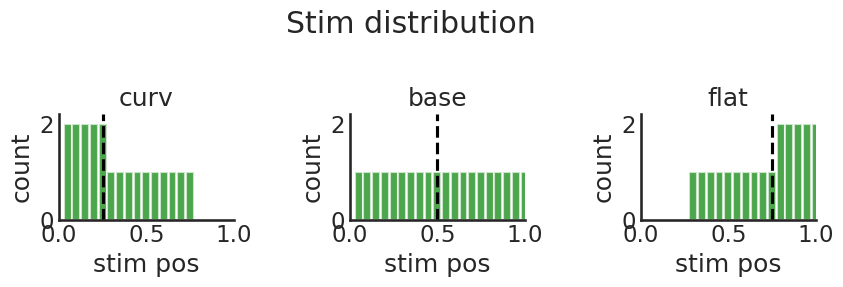

['curv', 'base', 'flat'] [0.25, 0.5, 0.75]
num unique trials: 60


,condition,stim,boundary,cond_unique_stim_idx,class
0,base,0.025,0.50,0,0
5,base,0.275,0.50,5,0
10,base,0.525,0.50,10,1
15,base,0.775,0.50,15,1
20,curv,0.025,0.25,0,0
25,curv,0.125,0.25,2,0
30,curv,0.275,0.25,5,1
35,curv,0.525,0.25,10,1
40,flat,0.275,0.75,0,0
45,flat,0.525,0.75,5,0


In [28]:
psychopy_df = pd.read_csv(f'../../inputs/psychopy/trials_patients_v2.csv', index_col=False)

# choose only 1st half of session, and every other trial
unique_trials_df = psychopy_df[:120][::2].copy().reset_index(drop=True)
assert len(unique_trials_df) == 60, "Expected 60 unique trials after filtering."

# renames
unique_trials_df = unique_trials_df.rename(columns={'stim_pos': 'stim', 'true_div': 'boundary'})
unique_trials_df['condition'] = unique_trials_df['condition'].map({'curv_comp': 'curv', 'baseline': 'base', 'flat_comp': 'flat'})

# drops
unique_trials_df.drop(columns=['blockN', 'trial_key', 'noise_pos', 'shape', 'run', 'div_pos', 'stim_file_pos', 'target_pos', 'marker_init', 'shape_order', 'valence', 'target_file', 'img1_file', 'img2_file', 'valence_direction', 'direction', 'marker_direction', 'noise_direction', 'shape_category'], inplace=True)
unique_trials_df.reset_index(drop=True, inplace=True)

# adds
# cond_unique_stim_idx: groups rows by unique stimulus & condition
unique_trials_df['cond_unique_stim_idx'] = unique_trials_df.groupby('boundary')['stim'].transform(lambda x: pd.factorize(x)[0])
unique_trials_df['class'] = (unique_trials_df['stim'] > unique_trials_df['boundary']).astype(int)  # 0 or 1 based on stim vs boundary

# norm stim and boundary to 0-1 range
unique_trials_df['stim']     = np.round((unique_trials_df['stim']     + 0.4) / 0.8, 4)
unique_trials_df['boundary'] = np.round((unique_trials_df['boundary'] + 0.4) / 0.8, 4)

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs, ax = axs.flatten(), 0
step = 0.04/.8  # ~ .05, fixed step between stim positions
plt.suptitle('Stim distribution')

bin_edges = np.arange(0 - step/2, 1 + step, step)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

for cond in ['curv', 'base', 'flat']:

    axs[ax].set(title=cond, xlabel='stim pos', ylabel='count', xlim=(0,1), ylim=(0, 2.2))
    cond_df = unique_trials_df[unique_trials_df['condition'] == cond]
    counts, _ = np.histogram(cond_df['stim'], bins=bin_edges)
    axs[ax].bar(bin_centers, counts, width=step*0.9, color='green', alpha=0.7, edgecolor='white')
    axs[ax].axvline(cond_df['boundary'].iloc[0], color='black', linestyle='--')
    ax += 1

plt.tight_layout()
plt.show()

print(conds, bounds)
print(f'num unique trials: {len(unique_trials_df)}')

unique_trials_df[::5]

generated noised repeats of unique trials

In [29]:
# repeats
n_trial_reps, trial_rep_noise = 10, 0.1       # noise added to X_train tensors (regularization)
all_trials_df = pd.concat([unique_trials_df.assign(rep=i) for i in range(n_trial_reps)], ignore_index=True)

# noise
rng = np.random.default_rng(seed)
all_trials_df['stim_noised'] = all_trials_df['stim'] + rng.normal(0, trial_rep_noise, size=len(all_trials_df))
# all_trials_df['boundary_noised'] = all_trials_df['boundary'] + rng.normal(0, trial_rep_noise, size=len(all_trials_df))

# show top row from each rep
all_trials_df.groupby('rep').first().reset_index()


,rep,condition,stim,boundary,cond_unique_stim_idx,class,stim_noised
0,0,base,0.025,0.5,0,0,-0.007824
1,1,base,0.025,0.5,0,0,-0.015878
2,2,base,0.025,0.5,0,0,0.033121
3,3,base,0.025,0.5,0,0,-0.077145
4,4,base,0.025,0.5,0,0,-0.067450
5,5,base,0.025,0.5,0,0,0.047042
6,6,base,0.025,0.5,0,0,0.116386
7,7,base,0.025,0.5,0,0,-0.027926
8,8,base,0.025,0.5,0,0,-0.053388
9,9,base,0.025,0.5,0,0,-0.126476


split into train/test

In [30]:
test_frac = 0.30
all_trials_df['train/test'] = ''
train_idx, test_idx = [], []

# grab each combo of unique_stim, cond, class
for _, unique_combo in all_trials_df.groupby(['cond_unique_stim_idx', 'condition', 'class']):
    combo_idxs = unique_combo.index.to_numpy().copy()
    np.random.default_rng(seed).shuffle(combo_idxs)
    n_test = int(np.round(len(combo_idxs) * test_frac))
    test_idx.extend(combo_idxs[:n_test])
    train_idx.extend(combo_idxs[n_test:])

all_trials_df.loc[train_idx, 'train/test'] = 'train'
all_trials_df.loc[test_idx, 'train/test'] = 'test'
train_df = all_trials_df.loc[train_idx].reset_index(drop=True)
test_df = all_trials_df.loc[test_idx].reset_index(drop=True)
eval_df = pd.concat([unique_trials_df] * 4, ignore_index=True) # to match expt and increase signal
 
print('number of trials:')
print(f'# unique trials: {len(unique_trials_df)}')
print(f'# all trials: {len(all_trials_df)}')
print(f'# train trials: {len(train_df)}')
print(f'# test trials: {len(test_df)}')
print(f'# eval trials: {len(eval_df)}')

all_trials_df.groupby('rep').first().reset_index()


number of trials:
# unique trials: 60
# all trials: 600
# train trials: 420
# test trials: 180
# eval trials: 240


,rep,condition,stim,boundary,cond_unique_stim_idx,class,stim_noised,train/test
0,0,base,0.025,0.5,0,0,-0.007824,train
1,1,base,0.025,0.5,0,0,-0.015878,train
2,2,base,0.025,0.5,0,0,0.033121,train
3,3,base,0.025,0.5,0,0,-0.077145,test
4,4,base,0.025,0.5,0,0,-0.067450,train
5,5,base,0.025,0.5,0,0,0.047042,train
6,6,base,0.025,0.5,0,0,0.116386,train
7,7,base,0.025,0.5,0,0,-0.027926,train
8,8,base,0.025,0.5,0,0,-0.053388,test
9,9,base,0.025,0.5,0,0,-0.126476,test


convert to tensors

In [31]:
# df -> tensors
def df_to_tensors(df, split):
    # noise for train, no noise for test
    if split == 'train': X = torch.tensor(df[['stim_noised', 'boundary']].values.copy(), dtype=torch.float32)
    else:                X = torch.tensor(df[['stim', 'boundary']].values.copy(), dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values.copy(), dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values.copy(), dtype=torch.float32)
    return X, y_class, y_stim

X_train, y_class_train, y_stim_train = df_to_tensors(train_df, 'train')
X_test, y_class_test, y_stim_test = df_to_tensors(test_df, 'test')
X_eval, y_class_eval, y_stim_eval = df_to_tensors(unique_trials_df, 'test')

print(f'train: X({X_train.shape}), y_class({y_class_train.shape}), y_stim({y_stim_train.shape})')
print(f'test: X({X_test.shape}), y_class({y_class_test.shape}), y_stim({y_stim_test.shape})')
print(f'eval: X({X_eval.shape}), y_class({y_class_eval.shape}), y_stim({y_stim_eval.shape})')

train: X(torch.Size([420, 2])), y_class(torch.Size([420, 1])), y_stim(torch.Size([420, 1]))
test: X(torch.Size([180, 2])), y_class(torch.Size([180, 1])), y_stim(torch.Size([180, 1]))
eval: X(torch.Size([60, 2])), y_class(torch.Size([60, 1])), y_stim(torch.Size([60, 1]))


### 2. network architecture, loss functions for train/test, model evaluation

architecture & parameters

In [32]:
# --- Architecture ---
class BoundaryNet(nn.Module):
    """
    2-input → 10-unit hidden → 2-output boundary network.
    Inputs   : [stim ∈ (0,1),  boundary ∈ {0.25, 0.50, 0.75}]
    Hidden   : 10 units, ReLU
    fc2_reg  : linear → graded position response
    fc2_class: linear → logit for BCE classification (dedicated head, targets 0/1)
    """
    def __init__(self, in_dim: int = 2, hidden_dim: int = 5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2_reg = nn.Linear(hidden_dim, 1)
        self.fc2_class = nn.Linear(hidden_dim, 1)

    def forward_with_hidden(self, x: torch.Tensor):
        """Return (position_output, class_logit, hidden_activations) for analysis."""
        hidden = F.relu(self.fc1(x))
        y_pred = self.fc2_reg(hidden)
        class_logit_pred = self.fc2_class(hidden)
        return y_pred, class_logit_pred, hidden

print('BoundaryNet, run_epoch, and evaluate_model_on_df defined.')
BoundaryNet()

def correlation_loss(pred, target):
    pred = pred.squeeze()
    target = target.squeeze()
    vx = pred - pred.mean()
    vy = target - target.mean()
    corr = (vx * vy).sum() / (torch.sqrt((vx ** 2).sum()) * torch.sqrt((vy ** 2).sum()) + 1e-8)
    return 1 - corr  # or -corr if you want to maximize

lr = 1e-2

# loss weights (0,1,.25 for CCN) (1,1,1 for newer)
bce_wt, mse_wt, exp_bound_wt = 1, 5, 0  # boundary-attraction MSE on expanded-class trials only
corr_wt = 0     # correlation y & y_pred

# convergence criteria
class_acc_target = .80
bce_loss_target, mse_target = 0.35, 0.005
min_epochs, max_epochs, conv_window = 15, 250, 20


BoundaryNet, run_epoch, and evaluate_model_on_df defined.


train/test setup

In [33]:
# full batch gradient descent (no dataloader) since dataset is small and we want to compute losses on all trials each epoch
def run_epoch(model, X, y_class, y_stim, optimizer=None):
    
    # if optimizer passed, we are in training mode, and gradients will be updated
    training = optimizer is not None
    model.train(training)

    with torch.set_grad_enabled(training):

        # predictions
        y_preds, class_logits, _ = model.forward_with_hidden(X)

        # get boundary location and whether class is expanded
        bounds = X[:, 1:2]  # boundary column (noised during train, clean during eval)
        are_exps = (((y_class == 0) & (bounds == .75)) | ((y_class == 1) & (bounds == 0.25))).squeeze(1)

        # losses
        mse_losses = F.mse_loss(y_preds, y_stim)

        if are_exps.any(): exp_bound_losses = F.mse_loss(y_preds[are_exps], bounds[are_exps])
        else:            exp_bound_losses = torch.tensor(0.0)

        bce_losses = F.binary_cross_entropy_with_logits(class_logits, y_class)

        corr_losses = correlation_loss(y_preds, y_stim)

        total_losses = (mse_wt * mse_losses) + (exp_bound_wt * exp_bound_losses) + corr_wt * corr_losses + bce_wt * bce_losses

        if training: optimizer.zero_grad(); total_losses.backward(); optimizer.step()

        n = X.size(0)
        correct = ((y_preds >= bounds).float() == y_class).sum().item()

    return {
        'total_losses':     total_losses.item(),
        'mse_losses':       mse_losses.item(),
        'exp_bound_losses': exp_bound_losses.item(),
        'bce_losses':       bce_losses.item(),
        'corr_losses':      corr_losses.item(),
        'class_acc':            correct / n,
    }


inference setup

In [34]:
def evaluate_model_on_df(model, unique_trials_df):

    X_eval, y_class_eval, y_stim_eval = df_to_tensors(unique_trials_df, 'test')

    model.eval()
    with torch.no_grad():  y_pred, class_logit_pred, hidden = model.forward_with_hidden(X_eval)

    pred_df = unique_trials_df.copy()
    pred_df['y_pred']       = y_pred.squeeze(1).numpy()
    pred_df['class_pred'] = (class_logit_pred.squeeze(1) > 0).float().numpy()

    perform_metrics = run_epoch(model, X_eval, y_class_eval, y_stim_eval)

    return pred_df, hidden.numpy(), perform_metrics


### 3. Run model
per network, train/test -> inference -> save

In [35]:
n_nets = 30
all_nets_detailed_res = [] # 1 row per net

for net_idx in range(n_nets):

    set_seed(seed + net_idx)
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)
    net_train_test_res, converged = [], False

    # 1. train/test
    for epoch in range(max_epochs):

        train_stats = run_epoch(model, X_train, y_class_train, y_stim_train, optimizer=optimizer)
        test_stats = run_epoch(model, X_test, y_class_test, y_stim_test)

        # store epoch, train/test losses, train/test accuracy
        train_test_res = {'net_idx': net_idx, 'epoch': epoch,
                     **{f"train_{k}": v for k, v in train_stats.items()},
                     **{f"test_{k}": v for k, v in test_stats.items()}}
        net_train_test_res.append(train_test_res)

        # decide whether to stop training based on convergence criteria
        if epoch >= min_epochs and len(net_train_test_res) >= conv_window:
            # acc based
            recent_test_acc = np.mean([e['test_class_acc']   for e in net_train_test_res[-conv_window:]])
            if recent_test_acc >= class_acc_target: converged = True; break

            # # BCE based
            # recent_test_bce = np.mean([e['test_bce_losses'] for e in net_train_test_res[-conv_window:]])
            # if recent_test_bce <= bce_loss_target: converged = True; break

    net_train_test_res_df = pd.DataFrame(net_train_test_res) # len = num_epochs

    # 2. inference on unseen, de-noised, eval trials
    net_inference_df, net_inference_hidden, net_inference_perform_metrics =\
        evaluate_model_on_df(model, eval_df)

    # 3. append. num_rows = num_nets.
    all_nets_detailed_res.append({
        'seed': seed + net_idx, 'model': model, 'net_idx': net_idx,
        'train_test_res_df': net_train_test_res_df, 'converged': converged, 'num_epochs': len(net_train_test_res_df),
        'inference_df': net_inference_df, 'inference_hidden_arr': net_inference_hidden, 'inference_performance_dict': net_inference_perform_metrics})

all_nets_summaries_df = pd.DataFrame({ 
    'seed':                [net['seed'] for net in all_nets_detailed_res],

    'train_total_loss':    [net['train_test_res_df']['train_total_losses'].iloc[-1] for net in all_nets_detailed_res],
    'train_class_acc':     [net['train_test_res_df']['train_class_acc'].iloc[-1] for net in all_nets_detailed_res],
    'test_total_loss':     [net['train_test_res_df']['test_total_losses'].iloc[-1] for net in all_nets_detailed_res],
    'test_class_acc':      [net['train_test_res_df']['test_class_acc'].iloc[-1] for net in all_nets_detailed_res],
    'converged':           [net['converged'] for net in all_nets_detailed_res],
    'num_epochs':          [net['num_epochs'] for net in all_nets_detailed_res],
        
    'inference_total_loss':     [net['inference_performance_dict']['total_losses'] for net in all_nets_detailed_res],
    'inference_class_acc':      [net['inference_performance_dict']['class_acc']    for net in all_nets_detailed_res]})

assert len(all_nets_summaries_df) == n_nets, f"Expected {n_nets} network summaries, got {len(all_nets_summaries_df)}"
print(f'len(all_nets_summaries_df) == n_nets')

all_nets_summaries_df.head()


len(all_nets_summaries_df) == n_nets


,seed,train_total_loss,train_class_acc,test_total_loss,test_class_acc,converged,num_epochs,inference_total_loss,inference_class_acc
0,20260309,0.714684,0.876190,0.693877,0.933333,True,40,0.693877,0.933333
1,20260310,0.709140,0.816667,0.686106,0.833333,True,38,0.686106,0.833333
2,20260311,0.698559,0.852381,0.679583,0.900000,True,62,0.679583,0.900000
3,20260312,0.681117,0.885714,0.660502,0.933333,True,54,0.660502,0.933333
4,20260313,0.709883,0.876190,0.684165,0.966667,True,42,0.684165,0.966667


example network

In [36]:
(all_nets_detailed_res[0]['inference_df'])

,condition,stim,boundary,cond_unique_stim_idx,class,y_pred,class_pred
0,base,0.025,0.50,0,0,0.254892,0.0
1,base,0.075,0.50,1,0,0.282880,0.0
2,base,0.125,0.50,2,0,0.310868,0.0
3,base,0.175,0.50,3,0,0.338856,0.0
4,base,0.225,0.50,4,0,0.366409,0.0
...,...,...,...,...,...,...,...
235,flat,0.875,0.75,12,1,0.826490,1.0
236,flat,0.925,0.75,13,1,0.829661,1.0
237,flat,0.925,0.75,13,1,0.829661,1.0
238,flat,0.975,0.75,14,1,0.832833,1.0


### 4. Check results

loss curves

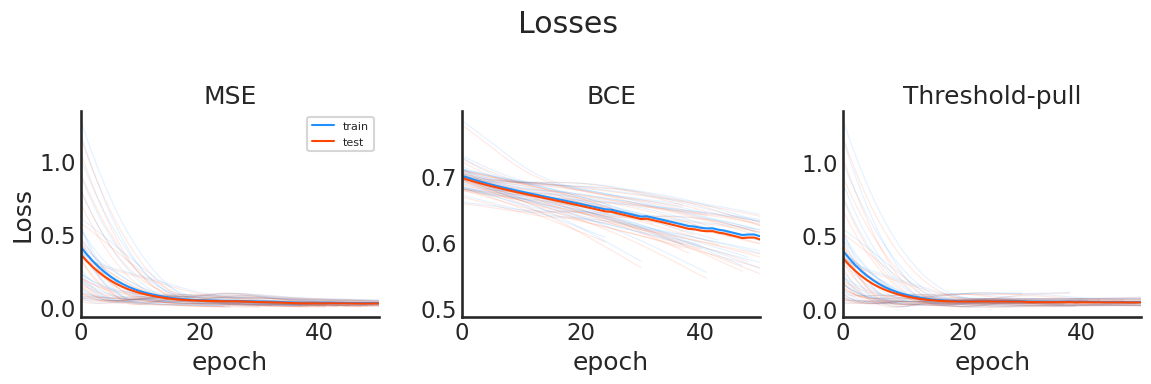

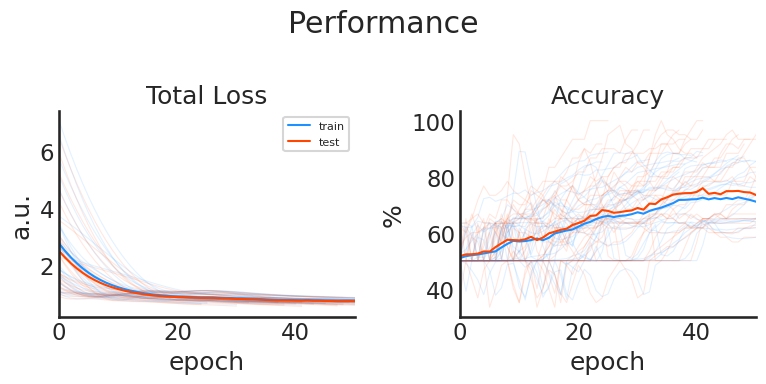

In [37]:
# ── Concatenate all per-epoch records across networks ─────────────────────────
all_epochs = pd.concat([net['train_test_res_df']
                        for net in all_nets_detailed_res], ignore_index=True)
epoch2plot = 50

# ── Losses ────────────────────────────────────────────────────────────────────
n_rows, n_cols = 1, 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()
plt.suptitle('Losses')

for ax, (title, train_col, test_col) in zip(axs, [
    ('MSE',      'train_mse_losses',      'test_mse_losses'),
    ('BCE',      'train_bce_losses',      'test_bce_losses'),
    ('Threshold-pull', 'train_exp_bound_losses','test_exp_bound_losses'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)
    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=1.5, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=1.5, label='test')
    ax.set(title=title, xlabel='epoch', ylabel='Loss' if title=='MSE' else '', xlim=(0, epoch2plot))

axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Performance ───────────────────────────────────────────────────────────────
n_rows, n_cols = 1, 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()
plt.suptitle('Performance')

for ax, (title, train_col, test_col) in zip(axs, [
    ('Total Loss', 'train_total_losses', 'test_total_losses'),
    ('Accuracy',   'train_class_acc',    'test_class_acc'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)
    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=1.5, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=1.5, label='test')
    ax.set(title=title, xlabel='epoch', xlim=(0, epoch2plot),
           ylabel='a.u.' if title == 'Total Loss' else '%')
    if title == 'Accuracy':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}'))
        
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


response distributions

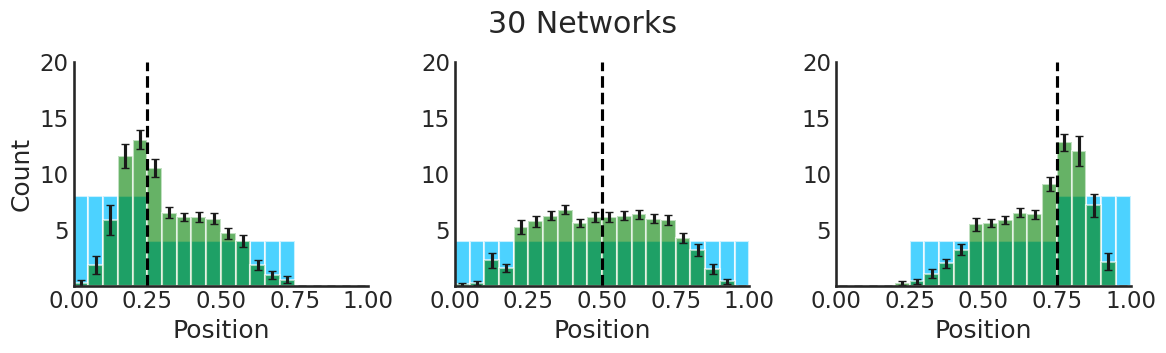

In [38]:
# collect all network predictions on eval set
inference_df = pd.concat([net['inference_df'].assign(net_idx=net['net_idx'])
                    for net in all_nets_detailed_res], ignore_index=True)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs, ax = axs.flatten(), 0
plt.suptitle(f'{n_nets} Networks', y=.9)
n_bins = 20
bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

for cond in conds:
    cond_df = inference_df[inference_df['condition'] == cond]
    axs[ax].set(xlabel='Position', ylabel='Count' if cond == conds[0] else '', xlim=(0, 1), ylim=(0,20),
                xticks=np.linspace(0, 1, 5), yticks=np.linspace(5, 20, 4))
    mean_nets_stim_cts = np.histogram(cond_df['stim'], bins=n_bins, range=(0,1))[0] / n_nets
    axs[ax].bar(bin_centers, mean_nets_stim_cts, width=1/n_bins, color='deepskyblue', alpha=0.7, capsize=3, label='stimulus')

    net_resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'): net_resp_cts.append(np.histogram(net_df['y_pred'], bins=n_bins, range=(0,1))[0])
    net_resp_cts = np.array(net_resp_cts)
    mean_nets_resp_cts = net_resp_cts.mean(0)
    sem_nets_resp_cts  = net_resp_cts.std(0) / np.sqrt(n_nets)

    axs[ax].bar(bin_centers, mean_nets_resp_cts, width=1/n_bins, color='green', alpha=0.6, yerr=sem_nets_resp_cts, capsize=3, label='response')
    axs[ax].axvline(cond_df['boundary'].iloc[0], color='black', linestyle='--')
    ax += 1

# axs[0].legend()
plt.tight_layout()
plt.show()

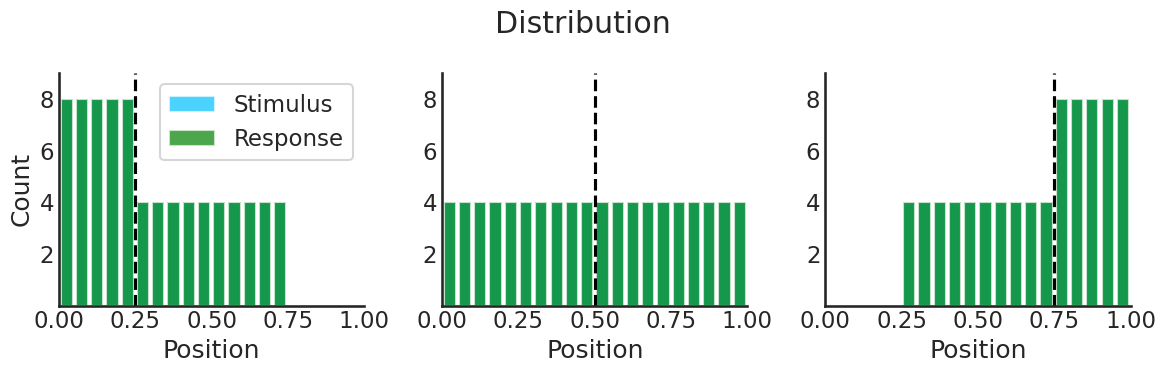

In [39]:
# collect all network predictions on eval set
inference_df = pd.concat([net['inference_df'].assign(net_idx=net['net_idx'])
                    for net in all_nets_detailed_res], ignore_index=True)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs, ax = axs.flatten(), 0
plt.suptitle(f'Distribution', y=.95)
n_bins = 20
bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

for cond in conds:
    cond_df = inference_df[inference_df['condition'] == cond]
    axs[ax].set(xlabel='Position', ylabel='Count' if cond == conds[0] else '', xlim=(0, 1), ylim=(0,9),
                xticks=np.linspace(0, 1, 5), yticks=np.linspace(2, 8, 4))
    mean_nets_stim_cts = np.histogram(cond_df['stim'], bins=n_bins, range=(0,1))[0] / n_nets
    axs[ax].bar(bin_centers, mean_nets_stim_cts, width=.04, color='deepskyblue', alpha=0.7, capsize=3, label='Stimulus')

    net_resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'): net_resp_cts.append(np.histogram(net_df['y_pred'], bins=n_bins, range=(0,1))[0])
    net_resp_cts = np.array(net_resp_cts)
    mean_nets_resp_cts = net_resp_cts.mean(0)
    sem_nets_resp_cts  = net_resp_cts.std(0) / np.sqrt(n_nets)

    axs[ax].bar(bin_centers, mean_nets_stim_cts, width=.04, color='green', alpha=0.7, capsize=3, label='Response')
    # axs[ax].bar(bin_centers, mean_nets_resp_cts, width=.04, color='green', alpha=0.6, yerr=sem_nets_resp_cts, capsize=3, label='Response')
    axs[ax].axvline(cond_df['boundary'].iloc[0], color='black', linestyle='--')
    ax += 1

axs[0].legend()
plt.tight_layout()
plt.show()

In [40]:
inference_df

,condition,stim,boundary,cond_unique_stim_idx,class,y_pred,class_pred,net_idx
0,base,0.025,0.50,0,0,0.254892,0.0,0
1,base,0.075,0.50,1,0,0.282880,0.0,0
2,base,0.125,0.50,2,0,0.310868,0.0,0
3,base,0.175,0.50,3,0,0.338856,0.0,0
4,base,0.225,0.50,4,0,0.366409,0.0,0
...,...,...,...,...,...,...,...,...
7195,flat,0.875,0.75,12,1,0.815150,1.0,29
7196,flat,0.925,0.75,13,1,0.858642,1.0,29
7197,flat,0.925,0.75,13,1,0.858642,1.0,29
7198,flat,0.975,0.75,14,1,0.902133,1.0,29


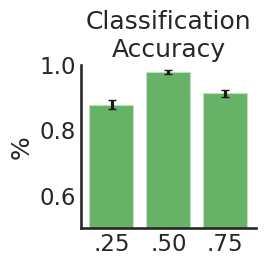

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.set(title=f'Classification\nAccuracy',
       ylabel='%', ylim=(0.5, 1), yticks=[.6, .8, 1], xticks=[0, 1, 2], xticklabels=['.25', '.50', '.75'])

for i, cond in enumerate(conds):
    cond_df = inference_df[inference_df['condition'] == cond]
    net_accs = []
    for _, net_df in cond_df.groupby('net_idx'):
        net_accs.append(((net_df['y_pred'] >= net_df['boundary']).astype(float) == net_df['class']).mean())
    net_accs = np.array(net_accs)
    mean_acc, sem = net_accs.mean(), net_accs.std() / np.sqrt(n_nets)
    ax.bar(i, mean_acc, color='green', alpha=0.6, yerr=sem, capsize=3)

plt.tight_layout()
plt.show()

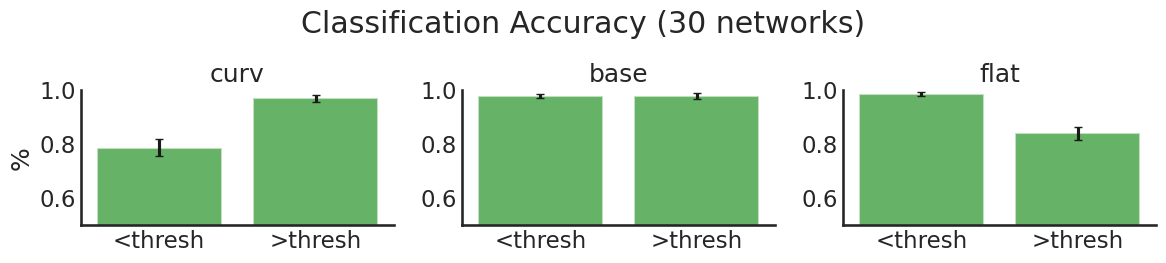

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(12,3))
axs, ax = axs.flatten(), 0
plt.suptitle(f'Classification Accuracy ({n_nets} networks)', y=.9)

for i, cond in enumerate(conds):
    cond_df = inference_df[inference_df['condition'] == cond]
    axs[ax].set(title=cond, ylabel='%' if cond == conds[0] else '', xlim=(-0.5, 1.5), ylim=(.5,1),
                xticks=[0, 1], xticklabels=['<thresh', '>thresh'], yticks=[.6, .8, 1])

    for category in [0, 1]: # get mean acc across nets for this category

        net_accs = [] # accuracy of each net for this category and condition
        for _, net_df in cond_df.groupby('net_idx'):
            category_df = net_df[net_df['class'] == category] # subset to this category
            net_accs.append(((category_df['y_pred'] >= category_df['boundary']).astype(float) == category_df['class']).mean())

        net_accs = np.array(net_accs)
        mean_nets_acc, sem = net_accs.mean(), net_accs.std() / np.sqrt(n_nets)
        axs[ax].bar(category, mean_nets_acc, color='green', alpha=0.6, yerr=sem, capsize=3)

    ax += 1

plt.tight_layout()
plt.show()

stimulus vs response, by context

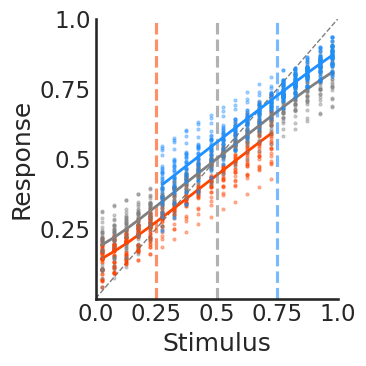

In [43]:
cond2color = {'curv': 'orangered', 'base': 'gray', 'flat': 'dodgerblue'}

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.set(xlabel='Stimulus', ylabel='Response', xlim=(0, 1), ylim=(0, 1),
       xticks=np.linspace(0, 1, 5), yticks=np.linspace(.25, 1, 4),
       xticklabels=np.linspace(0, 1, 5), yticklabels=np.linspace(.25, 1, 4))
ax.plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--', alpha=0.5)

for cond_i in range(len(conds)):
    cond, bound = conds[cond_i], bounds[cond_i]
    cond_df = inference_df[inference_df['condition'] == cond]
    
    ax.plot(cond_df['stim'], cond_df['y_pred'], 'o', markersize=2, alpha=0.1, color=cond2color[cond])
    ax.axvline(bound, color=cond2color[cond], linestyle='--', alpha=0.6)
    
    mean_resp = cond_df.groupby('stim')['y_pred'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=cond, color=cond2color[cond])

plt.tight_layout()
# plt.savefig('../../outputs/figs/ccn/beh-net-stim_vs_resp.svg', format='svg')
plt.show()


stim vs resp, context-aligned

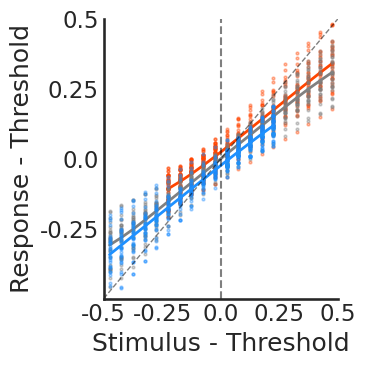

In [44]:
inference_df['stim_aligned'] = inference_df['stim'] - inference_df['boundary']
inference_df['resp_aligned'] = inference_df['y_pred'] - inference_df['boundary']

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.set(xlabel='Stimulus - Threshold', ylabel='Response - Threshold',
       xlim=(-0.5, 0.5), ylim=(-0.5, 0.5),
       xticks=np.linspace(-0.5, 0.5, 5), yticks=np.linspace(-0.5, 0.5, 5)[1:],
       xticklabels=np.linspace(-0.5, 0.5, 5), yticklabels=np.linspace(-0.5, 0.5, 5)[1:])

for cond in conds:
    cond_df = inference_df[inference_df['condition'] == cond]
    ax.plot(cond_df['stim_aligned'], cond_df['resp_aligned'], 'o', markersize=2, alpha=0.1, color=cond2color[cond])
    
    mean_resp = cond_df.groupby('stim_aligned')['resp_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=cond, color=cond2color[cond])

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([-0.5, 0.5], [-0.5, 0.5], color = 'black', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig('../../outputs/figs/ccn/beh-net-stim_vs_resp_aligned.svg', format='svg')
plt.show()


### test for context-shifts

In [45]:
# --- Between-context response divergence: raw vs aligned ---
from itertools import combinations
from scipy.stats import ttest_rel

def between_ctx_mse(net_df, stim_col, resp_col):
    pair_mses = []
    for c1, c2 in combinations(conds, 2):
        r1 = net_df[net_df['condition'] == c1].groupby(stim_col)[resp_col].mean()
        r2 = net_df[net_df['condition'] == c2].groupby(stim_col)[resp_col].mean()
        shared = r1.index.intersection(r2.index)
        if len(shared):
            pair_mses.append(np.mean((r1.loc[shared] - r2.loc[shared]) ** 2))
    return np.mean(pair_mses)

net_ids = inference_df['net_idx'].unique()
raw_divergence     = np.array([between_ctx_mse(inference_df[inference_df['net_idx'] == n], 'stim',         'y_pred')      for n in net_ids])
aligned_divergence = np.array([between_ctx_mse(inference_df[inference_df['net_idx'] == n], 'stim_aligned', 'resp_aligned') for n in net_ids])

print('Raw between-context MSE:    ', raw_divergence)
print('Aligned between-context MSE:', aligned_divergence)

Raw between-context MSE:     [0.04621698 0.0322043  0.03095432 0.04239956 0.00984645 0.00269323
 0.00556527 0.00905125 0.02348193 0.00986559 0.0149948  0.00445736
 0.00590282 0.00457634 0.00448944 0.00206336 0.008795   0.00577608
 0.0008279  0.00457894 0.00762625 0.01373028 0.00088227 0.00152105
 0.01456515 0.01403015 0.00012124 0.01149144 0.00169855 0.00152413]
Aligned between-context MSE: [0.00219915 0.00020972 0.00029073 0.00265181 0.00129565 0.00248347
 0.00011666 0.00211463 0.00369587 0.00190319 0.00058728 0.00855466
 0.00190445 0.00070035 0.00015544 0.00046911 0.00142196 0.00434394
 0.0061963  0.00173159 0.00192153 0.00488437 0.00686258 0.00269142
 0.00153401 0.00164784 0.00570418 0.0007173  0.00206932 0.00751723]


Paired t-test: t=3.613, p=0.00113


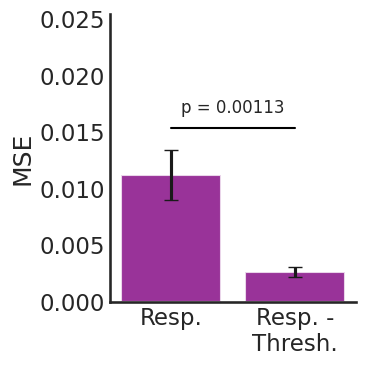

In [46]:
# --- Bar plot: raw vs aligned between-context divergence ---
t_stat, p_val = ttest_rel(raw_divergence, aligned_divergence)
print(f'Paired t-test: t={t_stat:.3f}, p={p_val:.3g}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

means = [raw_divergence.mean(), aligned_divergence.mean()]
sems  = [raw_divergence.std() / np.sqrt(len(raw_divergence)),
         aligned_divergence.std() / np.sqrt(len(aligned_divergence))]

ax.bar([0, 1], means, yerr=sems, capsize=5, color='purple', alpha=0.8)
ax.set(xticks=[0, 1], xticklabels=['Resp.', 'Resp. -\nThresh.'], ylabel='MSE')

line_y = max(m + s for m, s in zip(means, sems)) + 0.002
ax.plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)
ax.text(0.5, line_y + 0.001, f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
ax.set_ylim(0, line_y + 0.01)

plt.tight_layout()
# plt.savefig('../../outputs/figs/ccn/beh-net-context_divergence.svg', format='svg')
plt.show()

### 6. Check & save

In [47]:
print("inference_df columns:", inference_df.columns.tolist())
assert len(inference_df) == n_nets * len(eval_df), f"Expected {n_nets * len(eval_df)} rows in inference_df, got {len(inference_df)}"
print(f'len(inference_df) = n_nets * len(eval_df) = {len(inference_df)}')

inference_df.to_csv('../../outputs/simulations/inference_df.csv', index=False)
print('Saved: ../../outputs/simulations/inference_df.csv')

inference_df columns: ['condition', 'stim', 'boundary', 'cond_unique_stim_idx', 'class', 'y_pred', 'class_pred', 'net_idx', 'stim_aligned', 'resp_aligned']
len(inference_df) = n_nets * len(eval_df) = 7200
Saved: ../../outputs/simulations/inference_df.csv


In [48]:
hidden_stack = np.stack([nr['inference_hidden_arr'] for nr in all_nets_detailed_res], axis=0)
print(f'hidden_stack (n_nets, n_infer_trials, n_hidden_units): {hidden_stack.shape}')
# assert no NaNs or infs in hidden activations
assert not np.isnan(hidden_stack).any(), "Hidden activations contain NaN values."
assert not np.isinf(hidden_stack).any(), "Hidden activations contain inf values."

np.save('../../outputs/simulations/hidden_stack.npy', hidden_stack)   # shape (30, 60, 10)
print("Saved: ../../outputs/simulations/hidden_stack.npy")

hidden_stack (n_nets, n_infer_trials, n_hidden_units): (30, 240, 10)
Saved: ../../outputs/simulations/hidden_stack.npy
